# Compare Two-Stage Q-Learning Performance

This notebook compares the performance of Two-Stage Q-Learning vs standard Q-Learning approaches by fetching metrics from Azure ML experiments using MLflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from tqdm import tqdm

# Enable inline plotting
%matplotlib inline

# Move to root folder for imports
os.chdir(Path.cwd().parent)
from src.azureml_utils import download_runs_artifacts
from experiments.utils import (
    fetch_metrics_for_runs,
    compute_mean_and_ci,
    plot_mean_mre,
    plot_mean_mre_multi_ka,
    load_run_state_errors,
    compute_per_state_series,
    plot_per_state_error,
    plot_per_state_error_multi_ka,
    load_run_value_functions,
    compute_per_state_value_series,
    plot_per_state_value_multi_ka,
)

# Load environment variables from .env file
load_dotenv()


True

In [3]:
# Connect to Azure ML Workspace using SDK v2 and setup MLflow
# The workspace will be loaded from config.json file if available, or you can specify parameters
try:
    # Using DefaultAzureCredential for authentication
    credential = DefaultAzureCredential()
    credential.get_token("https://management.azure.com/.default")
    # Create ML Client from config.json
    ml_client = MLClient.from_config(credential=credential)
    print(f"Connected to workspace: {ml_client.workspace_name}")
    print(f"Subscription: {ml_client.subscription_id}")
    print(f"Resource group: {ml_client.resource_group_name}")

except Exception as e:
    print(f"Error connecting to workspace: {e}")
    raise

# Set up MLflow tracking URI for Azure ML
tracking_uri = ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri
mlflow.set_tracking_uri(tracking_uri)
print(f"✓ MLflow tracking URI set successfully to {mlflow.get_tracking_uri()}")

client = mlflow.tracking.MlflowClient()

Found the config file in: ./config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Connected to workspace: mlw-research-pro-003
Subscription: 706e41e6-9c7a-47c4-b231-c6e8897cfb63
Resource group: rg-research-pro-003
✓ MLflow tracking URI set successfully to azureml://westeurope.api.azureml.ms/mlflow/v2.0/subscriptions/706e41e6-9c7a-47c4-b231-c6e8897cfb63/resourceGroups/rg-research-pro-003/providers/Microsoft.MachineLearningServices/workspaces/mlw-research-pro-003


## Compare Q-Learning and Smart Q-Learning (N=5)

In [43]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs_size_5_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_5' OR tags.run_group = 'smart_5'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter = "1"  # set to None to include all two_stages runs
selected_ka_5 = ["5000", "35000", "75000"]              # e.g. ["5000", "50000"] or None to plot all

runs_size_5 = runs_size_5_all[
    (runs_size_5_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_5_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter is None
            or runs_size_5_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter
        )
        & (
            selected_ka_5 is None
            or runs_size_5_all["params.first_stage_steps"].isin(selected_ka_5)
        )
    )
]
runs_size_5.shape


(20, 57)

In [ ]:
download_runs_artifacts(
    run_names=runs_size_5["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)

In [44]:
metrics_size_5 = fetch_metrics_for_runs(client, runs_size_5, "log_mean_relative_error")
complete_size_5 = metrics_size_5[metrics_size_5["tags.learn_mode"] == "complete"]

two_stage_runs_5 = runs_size_5[runs_size_5["tags.learn_mode"] == "two_stages"]
available_ka_5 = sorted(
    two_stage_runs_5["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_5 = selected_ka_5 if selected_ka_5 is not None else available_ka_5

two_stage_size_5_series = []
for ka in ka_to_plot_5:
    run_ids = two_stage_runs_5[two_stage_runs_5["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_5[metrics_size_5["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_5_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=5 — Q-learning: {complete_size_5['run_id'].nunique()} runs")
for label, df in two_stage_size_5_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 20/20 [00:18<00:00,  1.07it/s]

Size=5 — Q-learning: 5 runs
  Smart Q-learning (K^a = 5,000): 5 runs
  Smart Q-learning (K^a = 35,000): 5 runs
  Smart Q-learning (K^a = 75,000): 5 runs


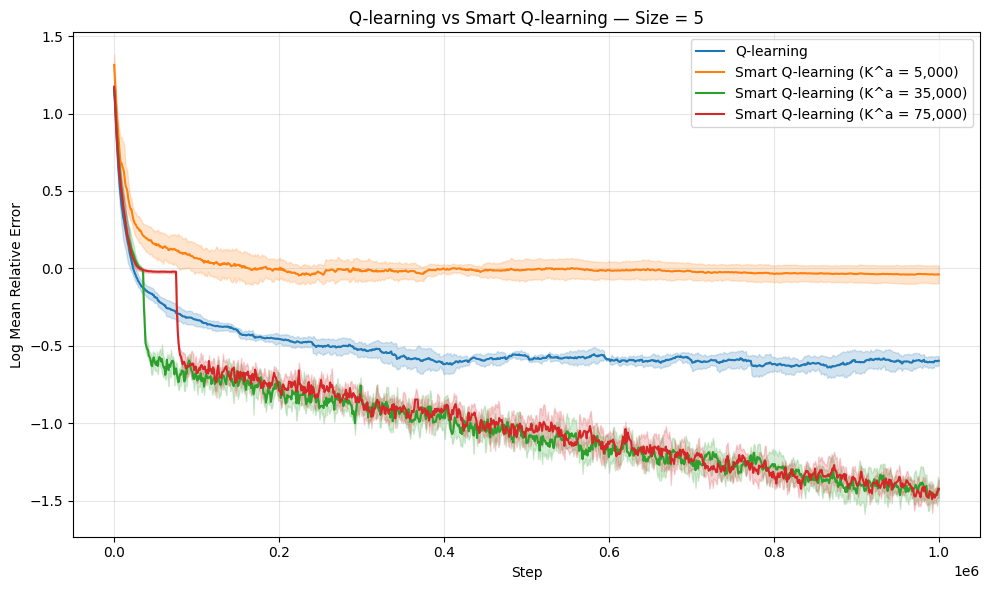

In [45]:
plot_mean_mre_multi_ka(
    complete_size_5,
    two_stage_size_5_series,
    "Q-learning vs Smart Q-learning — Size = 5",
)
plt.show()


In [8]:
states_errors_5 = {}
for _, row in tqdm(runs_size_5.iterrows(), total=len(runs_size_5)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_5[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_5.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_5.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_5)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


  0%|          | 0/20 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:280: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 20/20 [00:05<00:00,  3.87it/s]

Loaded 20 runs with local artifacts (5 complete, 15 two_stages)


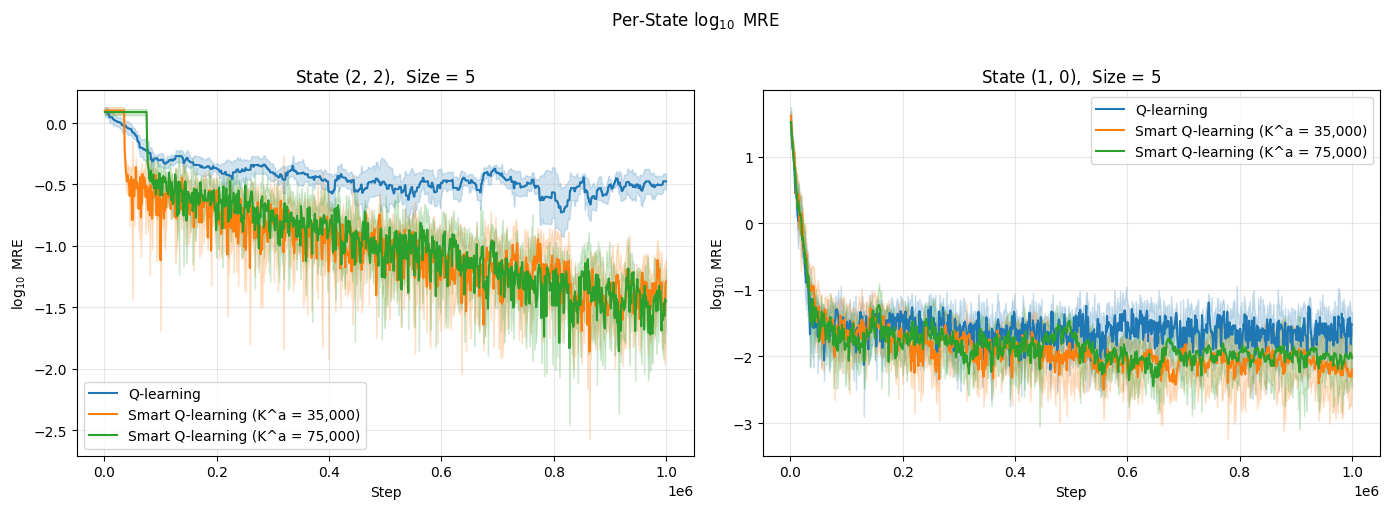

In [46]:
# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(2, 2), (1, 0)]

complete_per_state_errors_5 = {
    rid: v for rid, v in states_errors_5.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_5 = []
for ka in ka_to_plot_5:
    run_ids = set(two_stage_runs_5[two_stage_runs_5["params.first_stage_steps"] == ka]["run_id"])
    errors = {rid: v for rid, v in states_errors_5.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_5.append((f"K^a = {int(ka):,}", errors))

plot_per_state_error_multi_ka(
    complete_per_state_errors_5,
    two_stage_per_state_series_5,
    states_to_plot,
    size_label="Size = 5",
)
plt.show()


In [47]:
# ── Load raw value functions for Size = 5 ────────────────────────────
vf_5 = {}
for _, row in tqdm(runs_size_5.iterrows(), total=len(runs_size_5)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_5[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_5.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_5.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_5)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_5 = {
    rid: v for rid, v in vf_5.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_5 = []
for ka in ka_to_plot_5:
    run_ids = set(two_stage_runs_5[two_stage_runs_5["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_5.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_5.append((f"K^a = {int(ka):,}", vfs))


100%|██████████| 20/20 [00:23<00:00,  1.18s/it]

Loaded 20 runs with local value functions (5 complete, 15 two_stages)


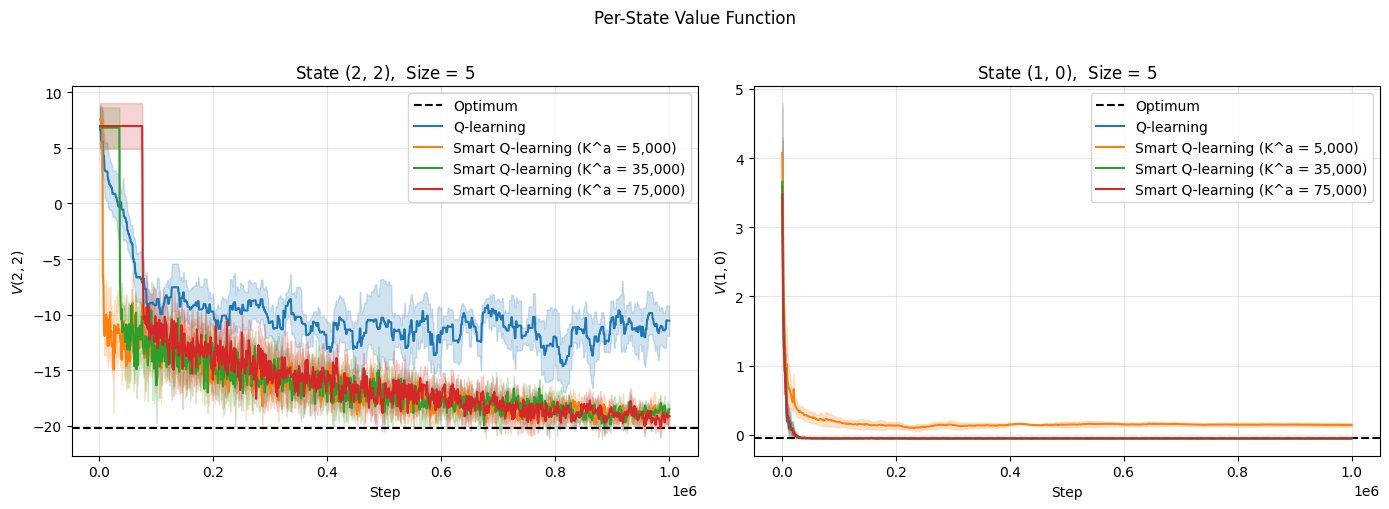

In [49]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(2, 2), (1, 0)]

plot_per_state_value_multi_ka(
    complete_vf_5,
    two_stage_vf_series_5,
    states_to_plot,
    size_label="Size = 5",
    log_values=False,
)
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=5, No reinfection)

In [12]:
runs_size_5_no_reinf_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_5_noreinf' or tags.run_group = 'smart_5_noreinf'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter_5nr = "1"  # set to None to include all two_stages runs
selected_ka_5_noreinf = ["5000", "55000"]          # e.g. ["5000", "55000"] or None to plot all

runs_size_5_no_reinf = runs_size_5_no_reinf_all[
    (runs_size_5_no_reinf_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_5_no_reinf_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter_5nr is None
            or runs_size_5_no_reinf_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter_5nr
        )
        & (
            selected_ka_5_noreinf is None
            or runs_size_5_no_reinf_all["params.first_stage_steps"].isin(selected_ka_5_noreinf)
        )
    )
]
runs_size_5_no_reinf.shape


(15, 57)

In [13]:
metrics_size_5_no_reinf = fetch_metrics_for_runs(client, runs_size_5_no_reinf)
complete_size_5_no_reinf = metrics_size_5_no_reinf[metrics_size_5_no_reinf["tags.learn_mode"] == "complete"]

two_stage_runs_5_noreinf = runs_size_5_no_reinf[runs_size_5_no_reinf["tags.learn_mode"] == "two_stages"]
available_ka_5_noreinf = sorted(
    two_stage_runs_5_noreinf["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_5_noreinf = selected_ka_5_noreinf if selected_ka_5_noreinf is not None else available_ka_5_noreinf

two_stage_size_5_noreinf_series = []
for ka in ka_to_plot_5_noreinf:
    run_ids = two_stage_runs_5_noreinf[two_stage_runs_5_noreinf["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_5_no_reinf[metrics_size_5_no_reinf["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_5_noreinf_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=5 no-reinfection — Q-learning: {complete_size_5_no_reinf['run_id'].nunique()} runs")
for label, df in two_stage_size_5_noreinf_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 15/15 [00:15<00:00,  1.01s/it]

Size=5 no-reinfection — Q-learning: 5 runs
  Smart Q-learning (K^a = 5,000): 5 runs
  Smart Q-learning (K^a = 55,000): 5 runs


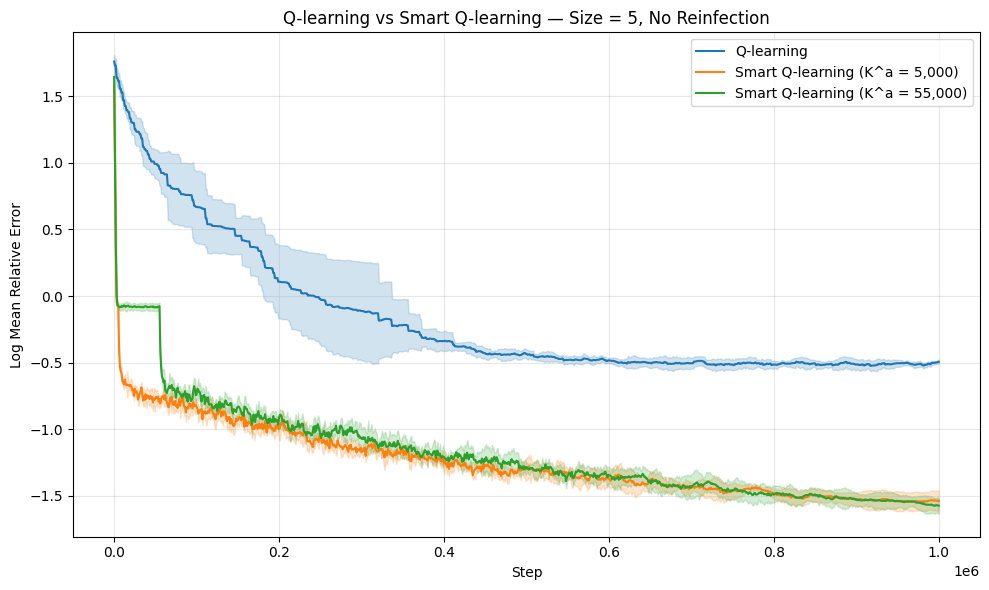

In [14]:
plot_mean_mre_multi_ka(
    complete_size_5_no_reinf,
    two_stage_size_5_noreinf_series,
    "Q-learning vs Smart Q-learning — Size = 5, No Reinfection",
)
plt.show()


In [15]:
download_runs_artifacts(
    run_names=runs_size_5_no_reinf["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)


Runs:   7%|▋         | 1/15 [00:01<00:16,  1.18s/run]

  wheat_cart_9yw252w7j9: 0 downloaded, 2012 skipped


Runs:  13%|█▎        | 2/15 [00:01<00:11,  1.09run/s]

  silly_curtain_4443f0t9np: 0 downloaded, 2012 skipped


Runs:  20%|██        | 3/15 [00:02<00:10,  1.14run/s]

...

Runs:  93%|█████████▎| 14/15 [00:09<00:00,  1.92run/s]

  boring_pen_wsd599qmk2: 0 downloaded, 1010 skipped


Runs: 100%|██████████| 15/15 [00:10<00:00,  1.44run/s]

  nifty_shoe_08k24fl6j6: 0 downloaded, 1010 skipped

Done — 15/15 runs succeeded (0 files downloaded, 25170 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


{'wheat_cart_9yw252w7j9': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/wheat_cart_9yw252w7j9'),
 'silly_curtain_4443f0t9np': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/silly_curtain_4443f0t9np'),
 'zen_tent_v3zrjjr7ym': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/zen_tent_v3zrjjr7ym'),
 'happy_knee_lrh3fdbgm8': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/happy_knee_lrh3fdbgm8'),
 'orange_avocado_3f3c3zp0zl': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/orange_avocado_3f3c3zp0zl'),
 'goofy_cushion_hjb3zcg9pb': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/goofy_cushion_hjb3zcg9pb'),
 'quiet_line_608z93s2dg': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/quiet_line_608z93s2dg'),
 'purple_rice_ypxw2y4rk8': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/

In [16]:
states_errors_5_noreinf = {}
for _, row in tqdm(runs_size_5_no_reinf.iterrows(), total=len(runs_size_5_no_reinf)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_5_noreinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_5_noreinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_5_noreinf.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_5_noreinf)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


  0%|          | 0/15 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:280: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 15/15 [00:24<00:00,  1.63s/it]

Loaded 15 runs with local artifacts (5 complete, 10 two_stages)


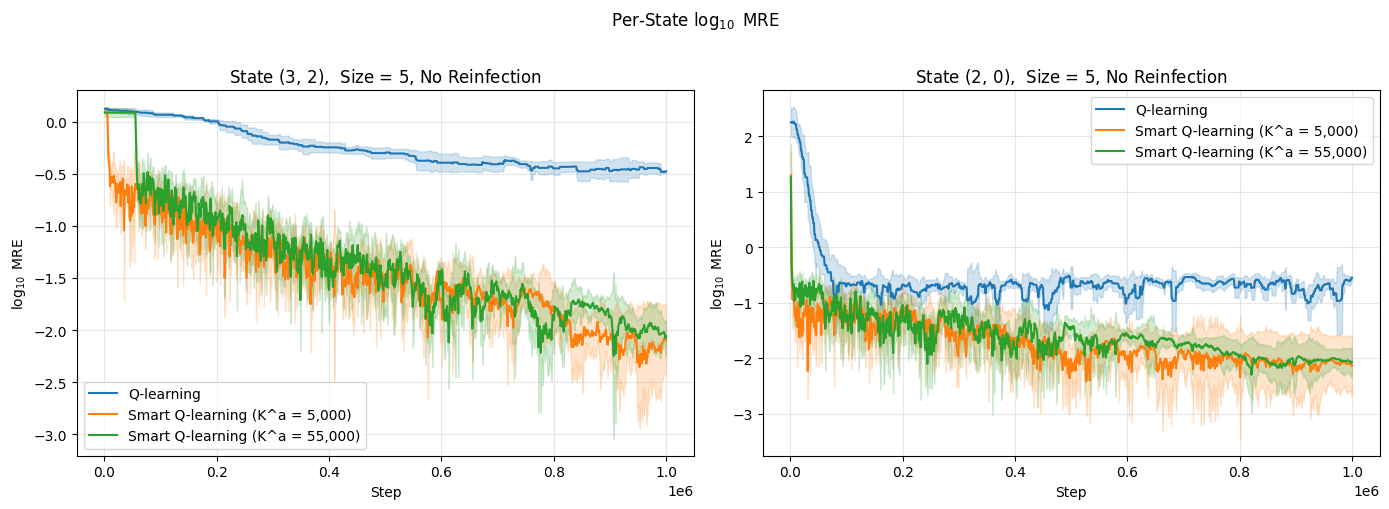

In [17]:
# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(3, 2), (2, 0)]

complete_per_state_errors_5_noreinf = {
    rid: v for rid, v in states_errors_5_noreinf.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_5_noreinf = []
for ka in ka_to_plot_5_noreinf:
    run_ids = set(
        two_stage_runs_5_noreinf[two_stage_runs_5_noreinf["params.first_stage_steps"] == ka]["run_id"]
    )
    errors = {rid: v for rid, v in states_errors_5_noreinf.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_5_noreinf.append((f"K^a = {int(ka):,}", errors))

plot_per_state_error_multi_ka(
    complete_per_state_errors_5_noreinf,
    two_stage_per_state_series_5_noreinf,
    states_to_plot,
    size_label="Size = 5, No Reinfection",
)
plt.show()


In [18]:
# ── Load raw value functions for Size = 5, No Reinfection ────────────────────────────
vf_5_noreinf = {}
for _, row in tqdm(runs_size_5_no_reinf.iterrows(), total=len(runs_size_5_no_reinf)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_5_noreinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_5_noreinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_5_noreinf.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_5_noreinf)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_5_noreinf = {
    rid: v for rid, v in vf_5_noreinf.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_5_noreinf = []
for ka in ka_to_plot_5_noreinf:
    run_ids = set(two_stage_runs_5_noreinf[two_stage_runs_5_noreinf["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_5_noreinf.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_5_noreinf.append((f"K^a = {int(ka):,}", vfs))


100%|██████████| 15/15 [00:17<00:00,  1.17s/it]

Loaded 15 runs with local value functions (5 complete, 10 two_stages)


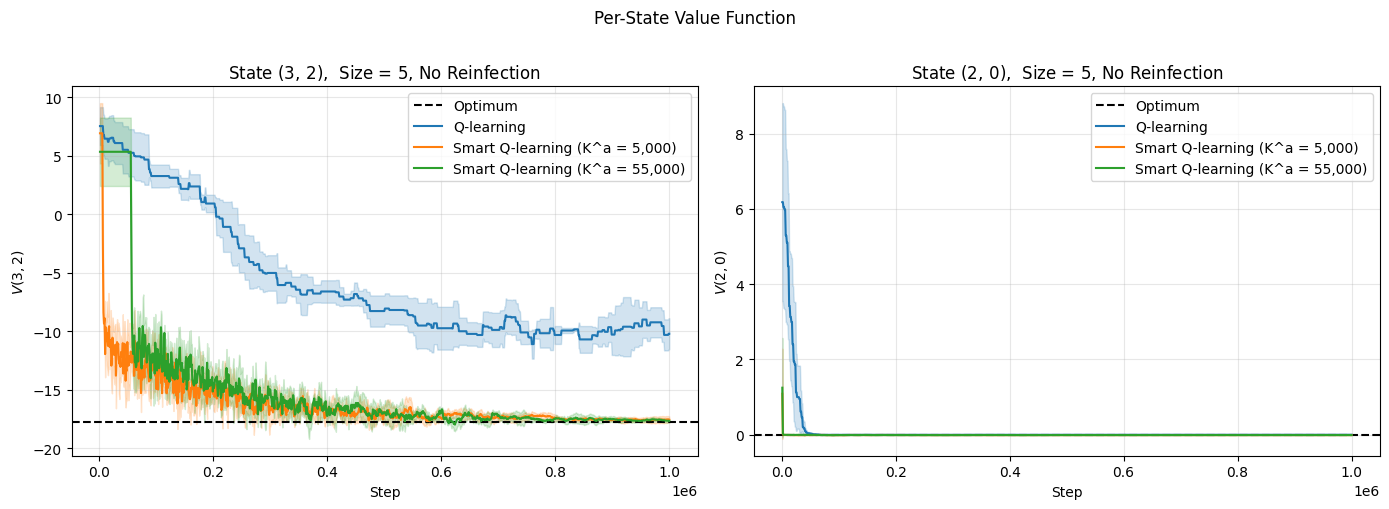

In [19]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(3, 2), (2, 0)]

plot_per_state_value_multi_ka(
    complete_vf_5_noreinf,
    two_stage_vf_series_5_noreinf,
    states_to_plot,
    size_label="Size = 5, No Reinfection",
)
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=10)

In [20]:
runs_size_10_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_10' OR tags.run_group = 'smart_10'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter_10 = "1"   # set to None to include all two_stages runs
selected_ka_10 = ["75000", "150000", "300000"]  # set to None to plot all

runs_size_10 = runs_size_10_all[
    (runs_size_10_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_10_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter_10 is None
            or runs_size_10_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter_10
        )
        & (
            selected_ka_10 is None
            or runs_size_10_all["params.first_stage_steps"].isin(selected_ka_10)
        )
    )
]

# Fetch metrics and build K^a series
metrics_size_10 = fetch_metrics_for_runs(client, runs_size_10)
complete_size_10 = metrics_size_10[metrics_size_10["tags.learn_mode"] == "complete"]

two_stage_runs_10 = runs_size_10[runs_size_10["tags.learn_mode"] == "two_stages"]
available_ka_10 = sorted(
    two_stage_runs_10["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_10 = selected_ka_10 if selected_ka_10 is not None else available_ka_10

two_stage_size_10_series = []
for ka in ka_to_plot_10:
    run_ids = two_stage_runs_10[two_stage_runs_10["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_10[metrics_size_10["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_10_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=10 — Q-learning: {complete_size_10['run_id'].nunique()} runs")
for label, df in two_stage_size_10_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 20/20 [00:20<00:00,  1.01s/it]

Size=10 — Q-learning: 5 runs
  Smart Q-learning (K^a = 105,000): 5 runs
  Smart Q-learning (K^a = 150,000): 5 runs
  Smart Q-learning (K^a = 300,000): 5 runs


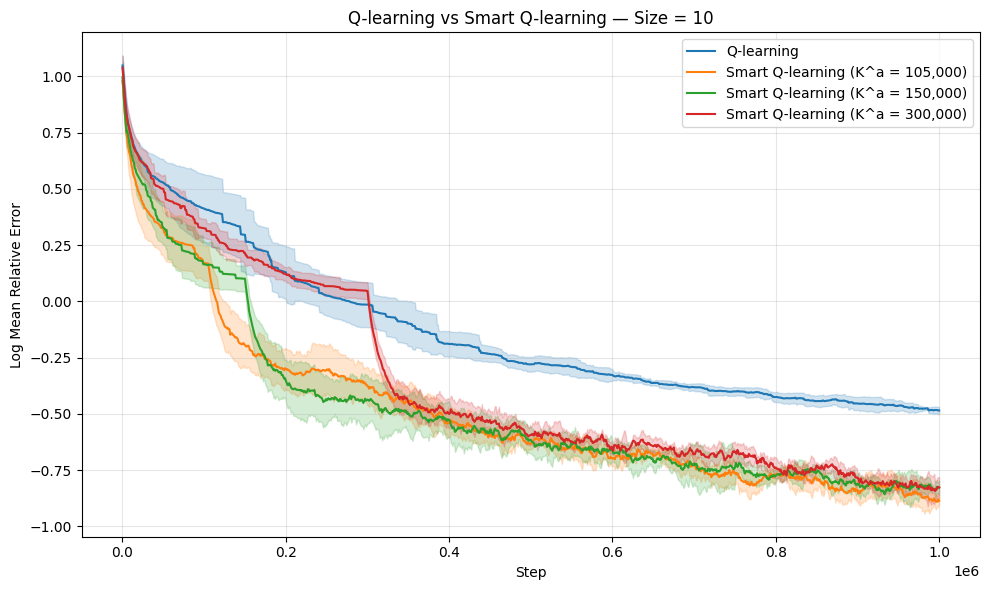

In [21]:
plot_mean_mre_multi_ka(
    complete_size_10,
    two_stage_size_10_series,
    "Q-learning vs Smart Q-learning — Size = 10",
)
plt.show()


In [22]:
download_runs_artifacts(
    run_names=runs_size_10["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)


Runs:   5%|▌         | 1/20 [00:01<00:23,  1.22s/run]

  hungry_ticket_f8jv0q6m0f: 0 downloaded, 2012 skipped


Runs:  10%|█         | 2/20 [00:02<00:18,  1.01s/run]

  icy_sprout_ssbvfrv77z: 0 downloaded, 2012 skipped


Runs:  15%|█▌        | 3/20 [00:02<00:15,  1.08run/s]

...

Runs:  95%|█████████▌| 19/20 [00:15<00:00,  1.87run/s]

  teal_pot_c794kgcf9q: 0 downloaded, 1010 skipped


Runs: 100%|██████████| 20/20 [00:15<00:00,  1.29run/s]

  heroic_milk_hdvy7t1szq: 0 downloaded, 1010 skipped

Done — 20/20 runs succeeded (0 files downloaded, 35230 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


{'hungry_ticket_f8jv0q6m0f': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/hungry_ticket_f8jv0q6m0f'),
 'icy_sprout_ssbvfrv77z': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/icy_sprout_ssbvfrv77z'),
 'coral_wheel_xxwkkqzpv8': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/coral_wheel_xxwkkqzpv8'),
 'amiable_oyster_kg2tzr67hw': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/amiable_oyster_kg2tzr67hw'),
 'patient_parsnip_s7jm0n2snx': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/patient_parsnip_s7jm0n2snx'),
 'polite_garlic_f19f16dmx9': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/polite_garlic_f19f16dmx9'),
 'green_arm_9sm244cqpk': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/green_arm_9sm244cqpk'),
 'magenta_button_b73nrggvp8': PosixPath('/Users/ccarballo/Projects/Research/epidemic-mod

In [23]:
states_errors_10 = {}
for _, row in tqdm(runs_size_10.iterrows(), total=len(runs_size_10)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_10[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_10.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_10.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_10)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


  0%|          | 0/20 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:280: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 20/20 [01:05<00:00,  3.29s/it]

Loaded 20 runs with local artifacts (5 complete, 15 two_stages)


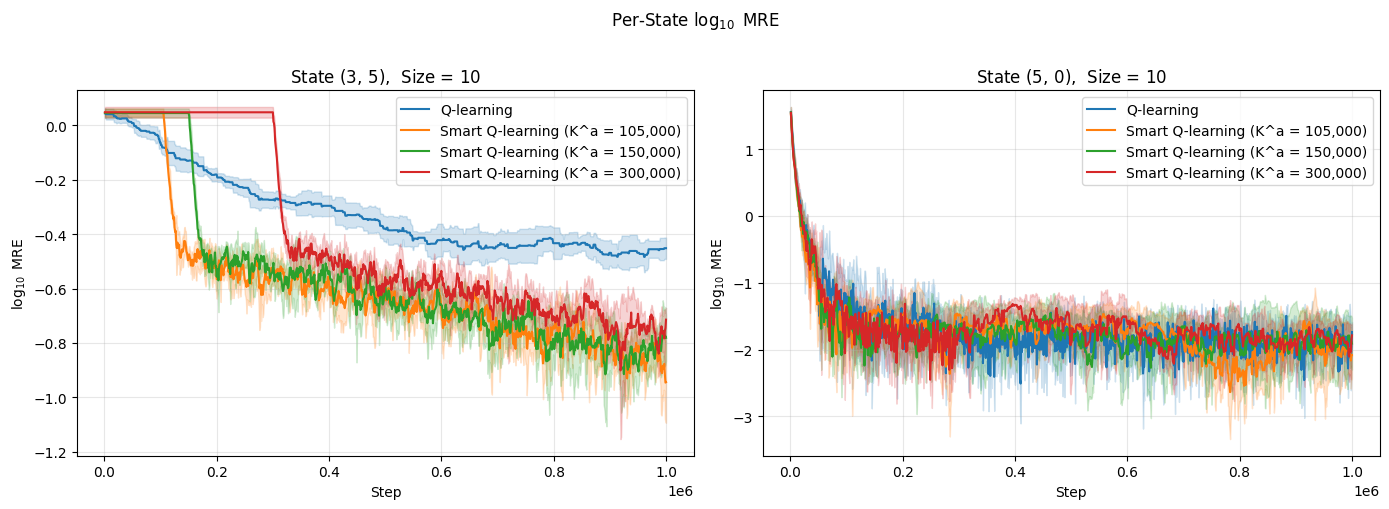

In [24]:
# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(3, 5), (5, 0)]

complete_per_state_errors_10 = {
    rid: v for rid, v in states_errors_10.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_10 = []
for ka in ka_to_plot_10:
    run_ids = set(
        two_stage_runs_10[two_stage_runs_10["params.first_stage_steps"] == ka]["run_id"]
    )
    errors = {rid: v for rid, v in states_errors_10.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_10.append((f"K^a = {int(ka):,}", errors))

plot_per_state_error_multi_ka(
    complete_per_state_errors_10,
    two_stage_per_state_series_10,
    states_to_plot,
    size_label="Size = 10",
)
plt.show()


In [25]:
# ── Load raw value functions for Size = 10 ────────────────────────────
vf_10 = {}
for _, row in tqdm(runs_size_10.iterrows(), total=len(runs_size_10)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_10[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_10.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_10.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_10)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_10 = {
    rid: v for rid, v in vf_10.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_10 = []
for ka in ka_to_plot_10:
    run_ids = set(two_stage_runs_10[two_stage_runs_10["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_10.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_10.append((f"K^a = {int(ka):,}", vfs))


100%|██████████| 20/20 [00:28<00:00,  1.43s/it]

Loaded 20 runs with local value functions (5 complete, 15 two_stages)


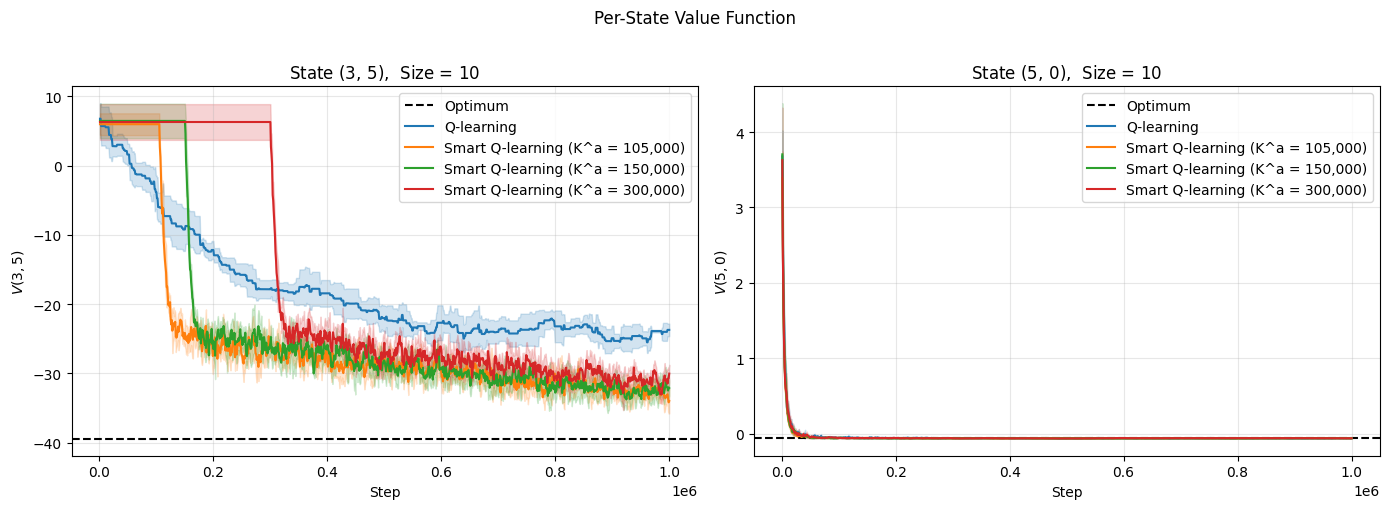

In [26]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(3, 5), (5, 0)]

plot_per_state_value_multi_ka(
    complete_vf_10,
    two_stage_vf_series_10,
    states_to_plot,
    size_label="Size = 10",
)
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=20)

In [ ]:
runs_size_20_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_20' OR tags.run_group = 'smart_20'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter_20 = "1"   # set to None to include all two_stages runs
selected_ka_20 = ["75000", "150000", "300000"]  # set to None to plot all

runs_size_20 = runs_size_20_all[
    (runs_size_20_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_20_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter_20 is None
            or runs_size_20_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter_20
        )
        & (
            selected_ka_20 is None
            or runs_size_20_all["params.first_stage_steps"].isin(selected_ka_20)
        )
    )
]

# Fetch metrics and build K^a series
metrics_size_20 = fetch_metrics_for_runs(client, runs_size_20)
complete_size_20 = metrics_size_20[metrics_size_20["tags.learn_mode"] == "complete"]

two_stage_runs_20 = runs_size_20[runs_size_20["tags.learn_mode"] == "two_stages"]
available_ka_20 = sorted(
    two_stage_runs_20["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_20 = selected_ka_20 if selected_ka_20 is not None else available_ka_20

two_stage_size_20_series = []
for ka in ka_to_plot_20:
    run_ids = two_stage_runs_20[two_stage_runs_20["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_20[metrics_size_20["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_20_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=20 — Q-learning: {complete_size_20['run_id'].nunique()} runs")
for label, df in two_stage_size_20_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


In [ ]:
plot_mean_mre_multi_ka(
    complete_size_20,
    two_stage_size_20_series,
    "Q-learning vs Smart Q-learning — Size = 20",
)
plt.show()


In [ ]:
download_runs_artifacts(
    run_names=runs_size_20["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)


In [ ]:
states_errors_20 = {}
for _, row in tqdm(runs_size_20.iterrows(), total=len(runs_size_20)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_20[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_20.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_20.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(states_errors_20)} runs with local artifacts "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)


In [ ]:
# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(5, 10), (10, 0)]

complete_per_state_errors_20 = {
    rid: v for rid, v in states_errors_20.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_20 = []
for ka in ka_to_plot_20:
    run_ids = set(
        two_stage_runs_20[two_stage_runs_20["params.first_stage_steps"] == ka]["run_id"]
    )
    errors = {rid: v for rid, v in states_errors_20.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_20.append((f"K^a = {int(ka):,}", errors))

plot_per_state_error_multi_ka(
    complete_per_state_errors_20,
    two_stage_per_state_series_20,
    states_to_plot,
    size_label="Size = 20",
)
plt.show()


In [ ]:
# ── Load raw value functions for Size = 20 ────────────────────────────
vf_20 = {}
for _, row in tqdm(runs_size_20.iterrows(), total=len(runs_size_20)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_20[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_20.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_20.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_20)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_20 = {
    rid: v for rid, v in vf_20.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_20 = []
for ka in ka_to_plot_20:
    run_ids = set(two_stage_runs_20[two_stage_runs_20["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_20.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_20.append((f"K^a = {int(ka):,}", vfs))


In [ ]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(5, 10), (10, 0)]

plot_per_state_value_multi_ka(
    complete_vf_20,
    two_stage_vf_series_20,
    states_to_plot,
    size_label="Size = 20",
)
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=50, No reinfection)

In [ ]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs_size_50_no_reinf_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_50_noreinf' OR tags.run_group = 'smart_50_noreinf'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter_50 = "1"  # set to None to include all two_stages runs
selected_ka_50 = ["10000", "50000", "100000", "150000", "300000"]               # e.g. ["10000", "50000", "100000"] or None to plot all

runs_size_50_no_reinf = runs_size_50_no_reinf_all[
    (runs_size_50_no_reinf_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_50_no_reinf_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter_50 is None
            or runs_size_50_no_reinf_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter_50
        )
        & (
            selected_ka_50 is None
            or runs_size_50_no_reinf_all["params.first_stage_steps"].isin(selected_ka_50)
        )
    )
]
runs_size_50_no_reinf.shape


(20, 57)

In [28]:
metrics_size_50_no_reinf = fetch_metrics_for_runs(client, runs_size_50_no_reinf)
complete_size_50_no_reinf = metrics_size_50_no_reinf[metrics_size_50_no_reinf["tags.learn_mode"] == "complete"]

two_stage_runs_50 = runs_size_50_no_reinf[runs_size_50_no_reinf["tags.learn_mode"] == "two_stages"]
available_ka_50 = sorted(
    two_stage_runs_50["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_50 = selected_ka_50 if selected_ka_50 is not None else available_ka_50

two_stage_size_50_no_reinf_series = []
for ka in ka_to_plot_50:
    run_ids = two_stage_runs_50[two_stage_runs_50["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_50_no_reinf[metrics_size_50_no_reinf["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_50_no_reinf_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=50 no-reinfection — Q-learning: {complete_size_50_no_reinf['run_id'].nunique()} runs")
for label, df in two_stage_size_50_no_reinf_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 20/20 [00:23<00:00,  1.15s/it]

Size=50 no-reinfection — Q-learning: 5 runs
  Smart Q-learning (K^a = 10,000): 5 runs
  Smart Q-learning (K^a = 50,000): 5 runs
  Smart Q-learning (K^a = 100,000): 5 runs


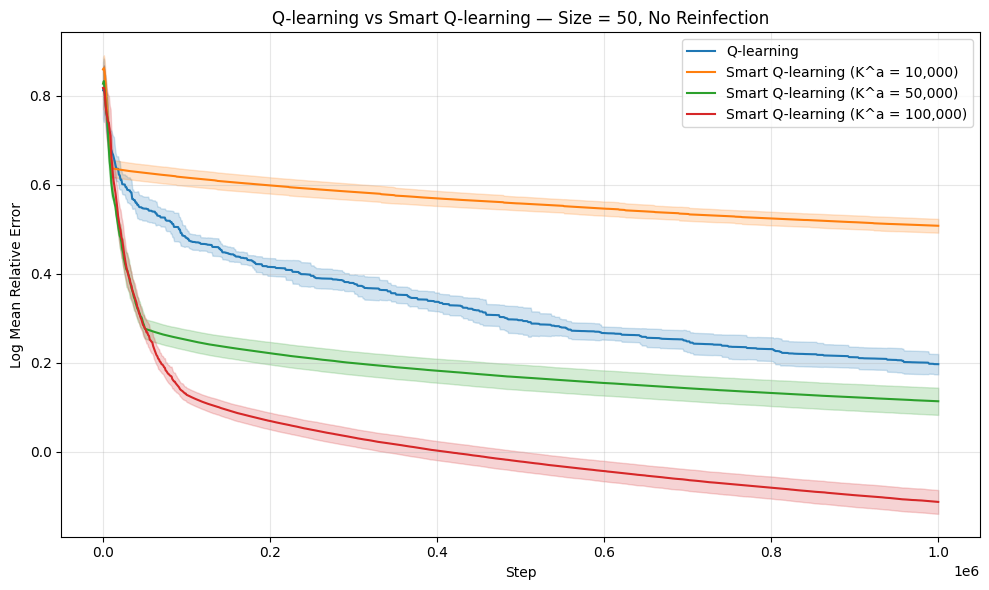

In [29]:
plot_mean_mre_multi_ka(
    complete_size_50_no_reinf,
    two_stage_size_50_no_reinf_series,
    "Q-learning vs Smart Q-learning — Size = 50, No Reinfection",
)
plt.show()


Runs:   5%|▌         | 1/20 [00:01<00:21,  1.13s/run]

  jolly_cherry_x9ynmd6xts: 0 downloaded, 2012 skipped


Runs:  10%|█         | 2/20 [00:01<00:17,  1.06run/s]

  serene_leaf_xxzzq1qn1m: 0 downloaded, 2012 skipped


Runs:  15%|█▌        | 3/20 [00:02<00:14,  1.15run/s]

...

  quiet_date_2hyl7kmtxr: 0 downloaded, 2012 skipped


Runs: 100%|██████████| 20/20 [00:16<00:00,  1.20run/s]


  red_insect_d2hnzy63bz: 0 downloaded, 2012 skipped

Done — 20/20 runs succeeded (0 files downloaded, 40240 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


  0%|          | 0/20 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:280: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 20/20 [01:38<00:00,  4.91s/it]


Loaded 20 runs (5 complete, 15 two_stages)


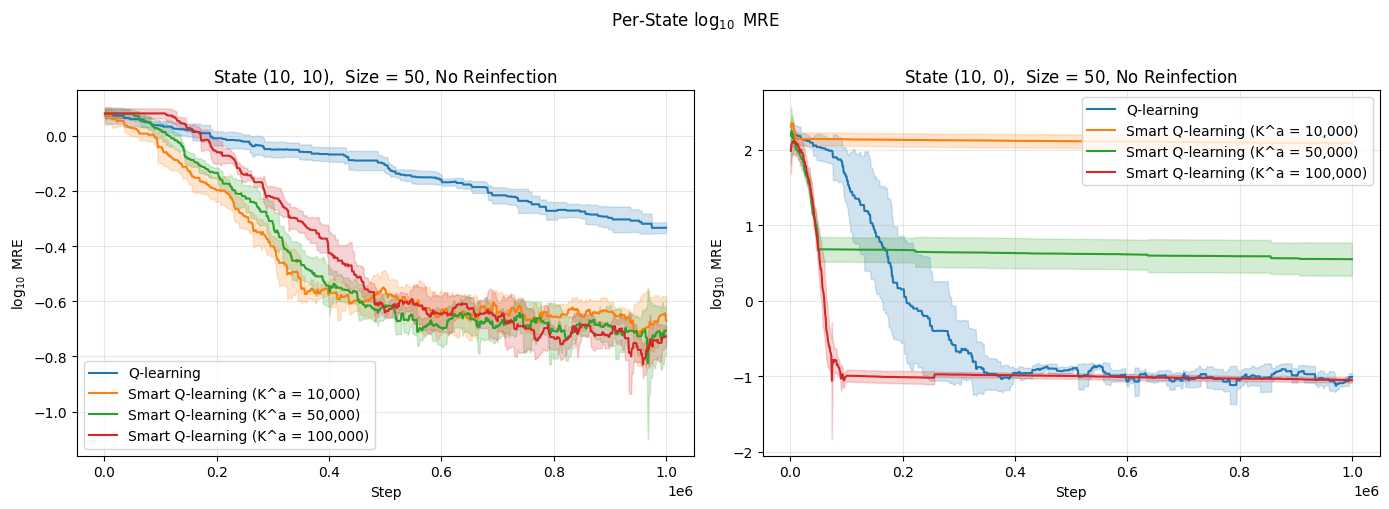

In [30]:
download_runs_artifacts(
    run_names=runs_size_50_no_reinf["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)

states_errors_50_no_reinf = {}
for _, row in tqdm(runs_size_50_no_reinf.iterrows(), total=len(runs_size_50_no_reinf)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_50_no_reinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_50_no_reinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_50_no_reinf.values() if v["learn_mode"] == "two_stages")
print(f"Loaded {len(states_errors_50_no_reinf)} runs ({n_complete} complete, {n_two_stages} two_stages)")

complete_per_state_errors_50 = {
    rid: v for rid, v in states_errors_50_no_reinf.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_50 = []
for ka in ka_to_plot_50:
    run_ids = set(
        two_stage_runs_50[two_stage_runs_50["params.first_stage_steps"] == ka]["run_id"]
    )
    errors = {rid: v for rid, v in states_errors_50_no_reinf.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_50.append((f"K^a = {int(ka):,}", errors))

# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(10, 10), (10, 0)]

plot_per_state_error_multi_ka(
    complete_per_state_errors_50,
    two_stage_per_state_series_50,
    states_to_plot,
    size_label="Size = 50, No Reinfection",
)
plt.show()


In [31]:
# ── Load raw value functions for Size = 50, No Reinfection ────────────────────────────
vf_50_noreinf = {}
for _, row in tqdm(runs_size_50_no_reinf.iterrows(), total=len(runs_size_50_no_reinf)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_50_noreinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_50_noreinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_50_noreinf.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_50_noreinf)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_50_noreinf = {
    rid: v for rid, v in vf_50_noreinf.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_50_noreinf = []
for ka in ka_to_plot_50:
    run_ids = set(two_stage_runs_50[two_stage_runs_50["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_50_noreinf.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_50_noreinf.append((f"K^a = {int(ka):,}", vfs))


100%|██████████| 20/20 [00:53<00:00,  2.68s/it]

Loaded 20 runs with local value functions (5 complete, 15 two_stages)


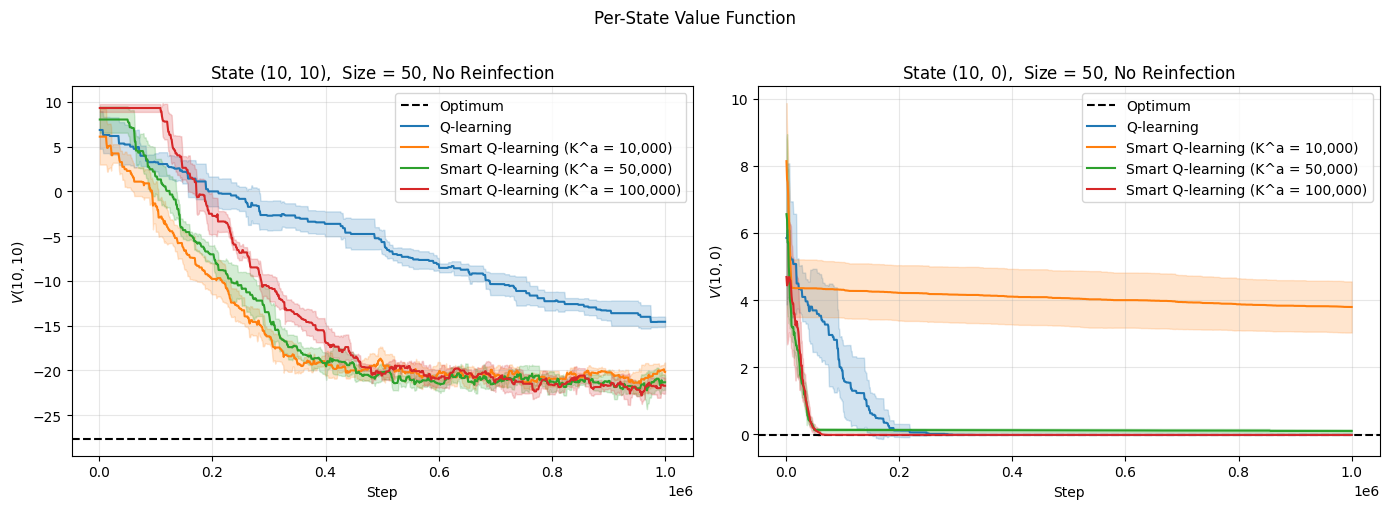

In [32]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(10, 10), (10, 0)]

plot_per_state_value_multi_ka(
    complete_vf_50_noreinf,
    two_stage_vf_series_50_noreinf,
    states_to_plot,
    size_label="Size = 50, No Reinfection",
)
plt.show()


## Compare Q-Learning and Smart Q-Learning (N=100, No reinfection)

In [33]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs_size_100_no_reinf_all = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.run_group = 'q_learning_100_noreinf' OR tags.run_group = 'smart_100_noreinf'",
    order_by=["start_time DESC"],
)

# ── Filter before downloading ──────────────────────────────────────────────
stage2_extra_steps_filter_100 = "1"  # set to None to include all two_stages runs
selected_ka_100 = ["100000", "250000", "500000"]  # e.g. ["100000", "250000", "500000"] or None to plot all

runs_size_100_no_reinf = runs_size_100_no_reinf_all[
    (runs_size_100_no_reinf_all["tags.learn_mode"] == "complete")
    | (
        (runs_size_100_no_reinf_all["tags.learn_mode"] == "two_stages")
        & (
            stage2_extra_steps_filter_100 is None
            or runs_size_100_no_reinf_all["params.stage2_absorbing_extra_steps"] == stage2_extra_steps_filter_100
        )
        & (
            selected_ka_100 is None
            or runs_size_100_no_reinf_all["params.first_stage_steps"].isin(selected_ka_100)
        )
    )
]
runs_size_100_no_reinf.shape


(20, 57)

In [34]:
metrics_size_100_no_reinf = fetch_metrics_for_runs(client, runs_size_100_no_reinf)
complete_size_100_no_reinf = metrics_size_100_no_reinf[metrics_size_100_no_reinf["tags.learn_mode"] == "complete"]

two_stage_runs_100 = runs_size_100_no_reinf[runs_size_100_no_reinf["tags.learn_mode"] == "two_stages"]
available_ka_100 = sorted(
    two_stage_runs_100["params.first_stage_steps"].dropna().unique(), key=lambda x: int(x)
)
ka_to_plot_100 = selected_ka_100 if selected_ka_100 is not None else available_ka_100

two_stage_size_100_no_reinf_series = []
for ka in ka_to_plot_100:
    run_ids = two_stage_runs_100[two_stage_runs_100["params.first_stage_steps"] == ka]["run_id"]
    df = metrics_size_100_no_reinf[metrics_size_100_no_reinf["run_id"].isin(run_ids)]
    if not df.empty:
        two_stage_size_100_no_reinf_series.append((f"K^a = {int(ka):,}", df))

print(f"Size=100 no-reinfection — Q-learning: {complete_size_100_no_reinf['run_id'].nunique()} runs")
for label, df in two_stage_size_100_no_reinf_series:
    print(f"  Smart Q-learning ({label}): {df['run_id'].nunique()} runs")


100%|██████████| 20/20 [00:19<00:00,  1.03it/s]

Size=100 no-reinfection — Q-learning: 5 runs
  Smart Q-learning (K^a = 100,000): 5 runs
  Smart Q-learning (K^a = 250,000): 5 runs
  Smart Q-learning (K^a = 500,000): 5 runs


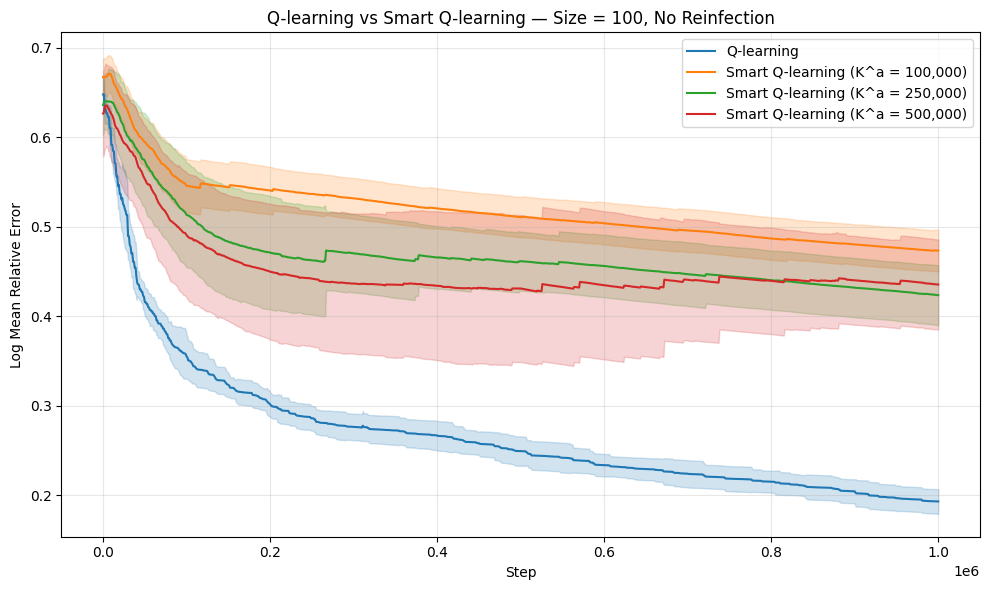

In [35]:
plot_mean_mre_multi_ka(
    complete_size_100_no_reinf,
    two_stage_size_100_no_reinf_series,
    "Q-learning vs Smart Q-learning — Size = 100, No Reinfection",
)
plt.show()


Runs:   5%|▌         | 1/20 [00:01<00:22,  1.18s/run]

  busy_reggae_kkkbkrzv4s: 0 downloaded, 2012 skipped


Runs:  10%|█         | 2/20 [00:02<00:17,  1.02run/s]

  coral_heart_4gnqzjx7k7: 0 downloaded, 2012 skipped


Runs:  15%|█▌        | 3/20 [00:02<00:14,  1.17run/s]

...

  eager_caravan_lm058clpk7: 0 downloaded, 2012 skipped


Runs: 100%|██████████| 20/20 [00:17<00:00,  1.16run/s]


  bubbly_soca_gthc6xkfsb: 0 downloaded, 2012 skipped

Done — 20/20 runs succeeded (0 files downloaded, 40240 skipped, 0 runs failed) → /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


  0%|          | 0/20 [00:00<?, ?it/s]/Users/ccarballo/Projects/Research/epidemic-models-rl/experiments/utils.py:280: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)  # (S+1, S+1)
100%|██████████| 20/20 [01:47<00:00,  5.38s/it]


Loaded 20 runs (5 complete, 15 two_stages)


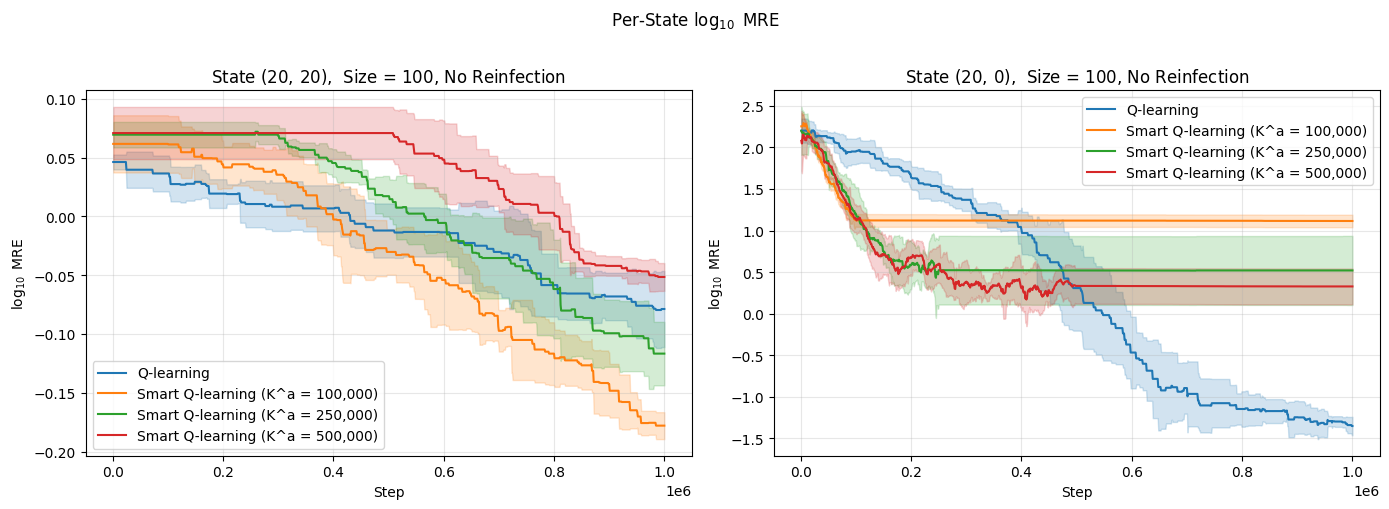

In [36]:
download_runs_artifacts(
    run_names=runs_size_100_no_reinf["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
    overwrite=False,
)

states_errors_100_no_reinf = {}
for _, row in tqdm(runs_size_100_no_reinf.iterrows(), total=len(runs_size_100_no_reinf)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        states_errors_100_no_reinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete = sum(1 for v in states_errors_100_no_reinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in states_errors_100_no_reinf.values() if v["learn_mode"] == "two_stages")
print(f"Loaded {len(states_errors_100_no_reinf)} runs ({n_complete} complete, {n_two_stages} two_stages)")

complete_per_state_errors_100 = {
    rid: v for rid, v in states_errors_100_no_reinf.items() if v["learn_mode"] == "complete"
}

two_stage_per_state_series_100 = []
for ka in ka_to_plot_100:
    run_ids = set(
        two_stage_runs_100[two_stage_runs_100["params.first_stage_steps"] == ka]["run_id"]
    )
    errors = {rid: v for rid, v in states_errors_100_no_reinf.items() if rid in run_ids}
    if errors:
        two_stage_per_state_series_100.append((f"K^a = {int(ka):,}", errors))

# ── Choose states to plot (any valid state with m_s + m_i <= size) ──
states_to_plot = [(20, 20), (20, 0)]

plot_per_state_error_multi_ka(
    complete_per_state_errors_100,
    two_stage_per_state_series_100,
    states_to_plot,
    size_label="Size = 100, No Reinfection",
)
plt.show()


In [37]:
# ── Load raw value functions for Size = 100, No Reinfection ────────────────────────────
vf_100_noreinf = {}
for _, row in tqdm(runs_size_100_no_reinf.iterrows(), total=len(runs_size_100_no_reinf)):
    vf = load_run_value_functions(row["run_id"])
    if vf is not None:
        vf_100_noreinf[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            **vf,
        }

n_complete = sum(1 for v in vf_100_noreinf.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in vf_100_noreinf.values() if v["learn_mode"] == "two_stages")
print(
    f"Loaded {len(vf_100_noreinf)} runs with local value functions "
    f"({n_complete} complete, {n_two_stages} two_stages)"
)

complete_vf_100_noreinf = {
    rid: v for rid, v in vf_100_noreinf.items() if v["learn_mode"] == "complete"
}

two_stage_vf_series_100_noreinf = []
for ka in ka_to_plot_100:
    run_ids = set(two_stage_runs_100[two_stage_runs_100["params.first_stage_steps"] == ka]["run_id"])
    vfs = {rid: v for rid, v in vf_100_noreinf.items() if rid in run_ids}
    if vfs:
        two_stage_vf_series_100_noreinf.append((f"K^a = {int(ka):,}", vfs))


100%|██████████| 20/20 [01:21<00:00,  4.07s/it]

Loaded 20 runs with local value functions (5 complete, 15 two_stages)


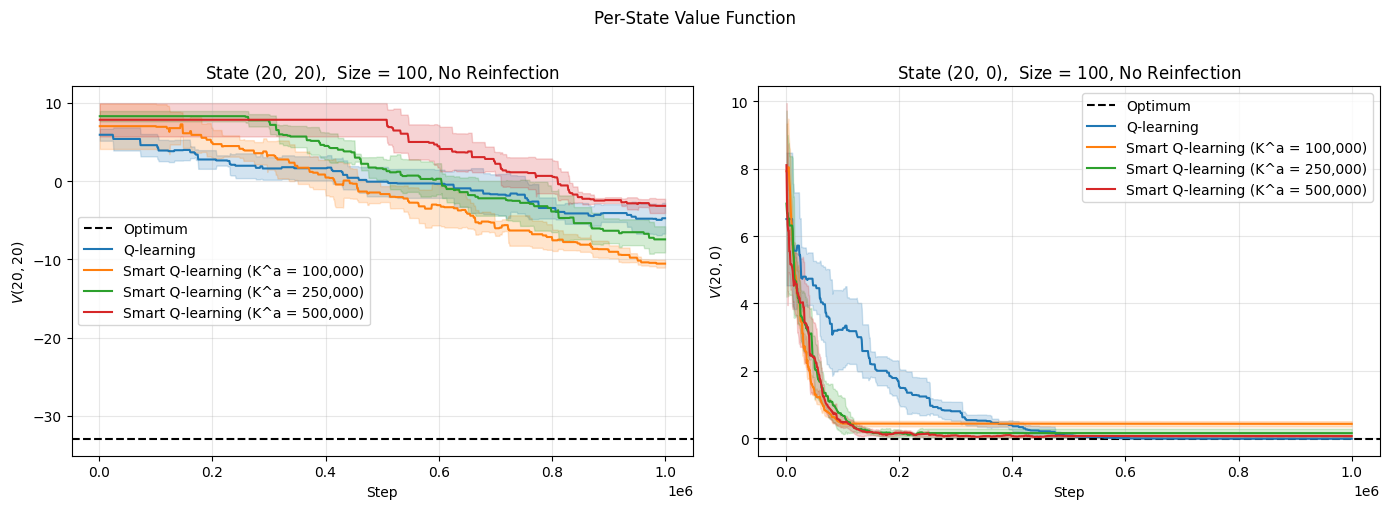

In [38]:
# ── Per-state value function ─────────────────────────────────────────────
states_to_plot = [(20, 20), (20, 0)]

plot_per_state_value_multi_ka(
    complete_vf_100_noreinf,
    two_stage_vf_series_100_noreinf,
    states_to_plot,
    size_label="Size = 100, No Reinfection",
)
plt.show()
